In [1]:
# These modules are required for the data reduction.
from dysh.fits.gbtfitsload import GBTFITSLoad
from dysh.log import init_logging

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(example="repeated")

16:08:05.421 I Resolving example=repeated -> repeated-scans/data/TRFI_090125_S1.raw.vegas/TRFI_090125_S1.raw.vegas.testtrim.fits


16:08:05.424 I url: http://www.gb.nrao.edu/dysh//example_data/repeated-scans/data/TRFI_090125_S1.raw.vegas/TRFI_090125_S1.raw.vegas.testtrim.fits


Odd-1, did not find /bigdisk/data/gbt/dysh_data/example_data/repeated-scans/data/TRFI_090125_S1.raw.vegas/TRFI_090125_S1.raw.vegas.testtrim.fits
TRFI_090125_S1.raw.vegas.testtrim.fits already downloaded


In [4]:
sdfits = GBTFITSLoad(filename)

In [5]:
sdfits.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
2,rfiscan1,0.0,Track,1,2.15,1,1,4,1,15.3022,44.5177
2,rfiscan2,0.0,Track,1,0.75,1,1,4,1,172.2867,44.5177


In [6]:
sdfits.summary(add_columns="BINTABLE, PROJID")

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION,BINTABLE,PROJID
2,rfiscan1,0.0,Track,1,2.15,1,1,4,1,15.3022,44.5177,0,TRFI_090125_S1
2,rfiscan2,0.0,Track,1,0.75,1,1,4,1,172.2867,44.5177,1,TRFI_090125_S1


In [7]:
tpsb1 = sdfits.gettp(scan=2, ifnum=0, plnum=0, fdnum=0, bintable=0)

In [8]:
tpsb2 = sdfits.gettp(scan=2, ifnum=0, plnum=0, fdnum=0, bintable=1)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/astropy/units/equivalencies.py:543: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((1 + beta) / (1 - beta)) - 1


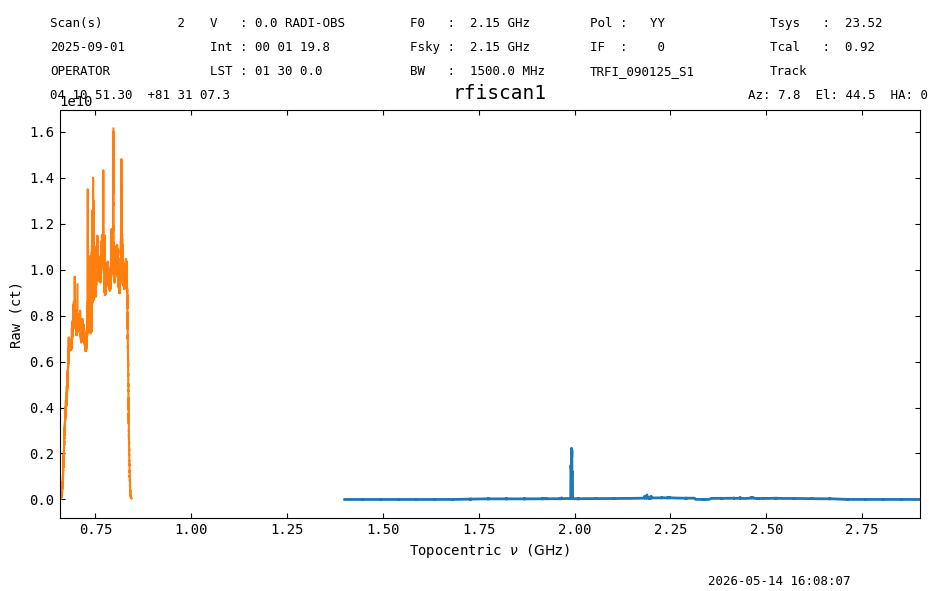

In [9]:
tpsb1_plt = tpsb1.timeaverage().plot(oshow=tpsb2.timeaverage(), xaxis_unit="GHz")

In [10]:
tpsb1.timeaverage().check_stats(81581261.43976656)

16:08:09.182 I rms is OK  (no unit was given, assumed ct)


In [11]:
tpsb2.timeaverage().check_stats(3.06388519e+09)

16:08:09.478 I rms is OK  (no unit was given, assumed ct)
